In [18]:
import sys
sys.path.append('../src')
from ModelTraining import *
from loader_cleaner import load_csv
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
cc = load_csv('../data/raw/creditcard.csv')


In [ ]:
X_train, y_train, X_test, y_test = load_split(cc, target_col='Class')

In [5]:
lr = get_logistic_regression()
lr = train_model(lr, X_train, y_train)

lr_result = evaluate_model(lr, X_test, y_test)
lr_result

{'f1 ': 0.07540846250523671,
 'auc_pr ': 0.691137982048524,
 'confusion matrix ': array([[54665,  2199],
        [    8,    90]], dtype=int64)}

In [6]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
scale_pos_weight

577.2868020304569

In [7]:
xgb_model = get_xgboost(scale_pos_weight)
xgb_model = train_model(xgb_model, X_train, y_train)

xgb_result = evaluate_model(xgb_model, X_test, y_test)
xgb_result


c:\Users\ruthg\OneDrive\Desktop\KIFYA Tasks\Adey_Fraud_Detection-Week5\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:24:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'f1 ': 0.8541666666666667,
 'auc_pr ': 0.8719366258679776,
 'confusion matrix ': array([[56852,    12],
        [   16,    82]], dtype=int64)}

In [8]:
X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

In [10]:
lr_cv = cross_validate_model(model_class=get_logistic_regression, X=X_full, y=y_full)
lr_cv

{'f1_mean': 0.08652900688298917,
 'f1_std': 0.0,
 'auc_pr_mean': 0.6587209047913613,
 'auc_pr_std': 0.0}

In [11]:
xgb_cv = cross_validate_model(model_class=get_xgboost, X=X_full, y=y_full, scale_pos_weight=scale_pos_weight)
xgb_cv

c:\Users\ruthg\OneDrive\Desktop\KIFYA Tasks\Adey_Fraud_Detection-Week5\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:30:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'f1_mean': 0.8743169398907102,
 'f1_std': 0.0,
 'auc_pr_mean': 0.8377099975385985,
 'auc_pr_std': 0.0}

In [13]:
cv_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'F1 Mean': [lr_cv['f1_mean'], xgb_cv['f1_mean']],
    'F1 Std': [lr_cv['f1_std'], xgb_cv['f1_std']],
    'AUC-PR Mean': [lr_cv['auc_pr_mean'], xgb_cv['auc_pr_mean']],
    'AUC-PR Std': [lr_cv['auc_pr_std'], xgb_cv['auc_pr_std']]
})

cv_comparison

,Model,F1 Mean,F1 Std,AUC-PR Mean,AUC-PR Std
0,Logistic Regression,0.086529,0.0,0.658721,0.0
1,XGBoost,0.874317,0.0,0.837710,0.0


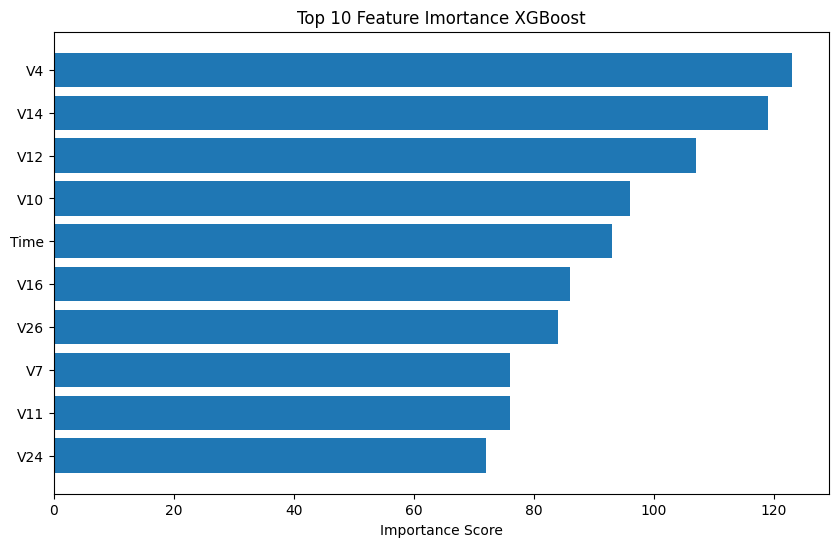

In [19]:
importance = xgb_model.get_booster().get_score(importance_type='weight')
importance_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'][:10][::-1], importance_df['importance'][:10][::-1])
plt.title("Top 10 Feature Imortance XGBoost")
plt.xlabel("Importance Score")
plt.show()